# Lab 4.3: Model Diagnosis

In this lab you will implement the training set size experiment described in class, and also explore transfer learning using a pre-trained convolutional neural network (CNN) for image classification.

We will use the [Intel Image Classification dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification).

In [3]:
!wget -nc -q -O intel_image_classification.zip "https://www.dropbox.com/scl/fi/7a69ka8kpdw40pm6uz91t/intel_image_classification.zip?rlkey=3knd7qsk6cvecw1mq7ohk39ot&dl=1"
!unzip -n -q intel_image_classification.zip

In [4]:
import glob
import imageio
import skimage
from matplotlib import pyplot as plt
import numpy as np

import torch
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from tqdm import tqdm


Here is some code to load the dataset.

In [5]:
label_names = ['buildings','forest','glacier','mountain','sea','street']

In [6]:
def load_split(split):
    images = []
    labels = []
    for label in label_names:
        image_paths = sorted(glob.glob(f'intel_image_classification/seg_{split}/{label}/*.jpg'))
        for path in tqdm(image_paths, desc=f'Loading {split} images for {label}'):
            image = imageio.imread(path)
            if len(image.shape)<3:
                continue
            if image.shape[2]!=3:
                continue
            images.append(torch.tensor(image).permute(2,0,1))
            labels.append(label)
    return images, np.array(labels)

train_images, train_labels = load_split('train')
test_images, test_labels = load_split('test')

Loading train images for buildings:   0%|          | 0/2191 [00:00<?, ?it/s]/tmp/ipykernel_950/1970331604.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)
Loading test images for street: 100%|██████████| 501/501 [00:00<00:00, 1093.62it/s]


Text(0.5, 1.0, 'buildings')

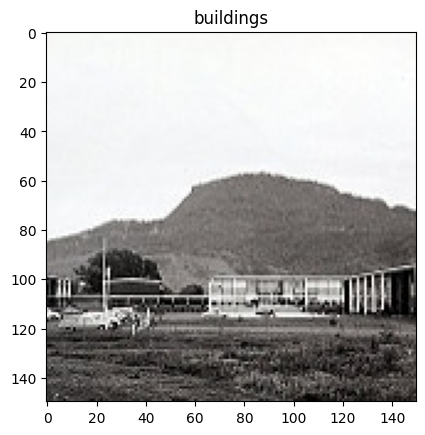

In [7]:
plt.imshow(train_images[0].permute(1,2,0))
plt.title(train_labels[0])

Here we randomly shuffle the training set, to support our later experiments.

In [8]:
inds = list(range(len(train_images)))
np.random.shuffle(inds)
train_images = [train_images[i] for i in inds]
train_labels = train_labels[inds]

Now we have arrays `train_images` and `train_labels` containing the images and labels for the training set, and the same for the test set.

Here we create a [MobileNetV2](https://arxiv.org/abs/1801.04381) model and download its pre-trained weights.  MobileNetV2 is a lightweight but high-performing convolutional neural network.  This version has been pre-trained on the ImageNet-1K dataset.

On Colab, go to `Runtime > Change Runtime Type` and select `T4 GPU` to make the CNN run faster.

In [9]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

weights = MobileNet_V2_Weights.IMAGENET1K_V2
mobilenet = mobilenet_v2(weights=weights)
# remove last layer
mobilenet.classifier = torch.nn.Sequential(*list(mobilenet.classifier.children())[:-1])
mobilenet = mobilenet.to(device)
mobilenet.eval()
transforms = weights.transforms()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 216MB/s]


This function will properly process the image and run MobileNetV2 to extract a feature vector.

In [10]:
def run_mobilenet(image):
    image = transforms(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet(image)
    return output[0].cpu().numpy()

1. Compute a MobileNetV2 descriptor for each image to make two lists, `train_descriptors` and `test_descriptors`, using the `run_mobilenet` function from above.

In [11]:
# CODE GOE HERE
train_descriptors = []
for image in train_images:
  train_descriptors.append(run_mobilenet(image))

test_descriptors = []
for image in test_images:
  test_descriptors.append(run_mobilenet(image))


2. Build a k-nearest neighbors classifier on the training set (```sklearn.neighbors.KNeighborsClassifier```).

This model will find the $k$ nearest neighbors to the query point and output the most common label.  Use $k=10$.

Run the model on the training and testing sets and print out the accuracy score for each (```sklearn.metrics.accuracy_score``` or simply use ```model.score```).

In [12]:
# CODE GOES HERE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(train_descriptors, train_labels)

train_predictions = knn_model.predict(train_descriptors)
test_predictions = knn_model.predict(test_descriptors)
accuracy_score(train_labels, train_predictions), accuracy_score(test_labels, test_predictions)

(0.9214764144221177, 0.918)

3. Now let's explore how train and test accuracy change as training set size increases.

We will test a range of training set sizes in increments of 1000 (so 1000, 2000, 3000, ... up to the original size of the training set).

For each size setting $s$, fit a ```kNeighborsClassifer``` model to the first $s$ examples in the training set.   Use $k=10$.

Then compute the accuracy of the model on the chosen subset of the training set, and the entire test set.  *Note: always use the entire test set!*


In [17]:
# CODE GOES HERE
train_scores = []
test_scores = []
sizes = []

for i in range(1000, len(train_labels), 1000):
  model = KNeighborsClassifier(n_neighbors=10).fit(train_descriptors[:i], train_labels[:i])
  train_score = accuracy_score(train_labels, model.predict(train_descriptors))
  test_score = accuracy_score(test_labels, model.predict(test_descriptors))

  train_scores.append(train_score)
  test_scores.append(test_score)
  sizes.append(i)

  print(f"Train accuracy using {i} examples: {train_score:.4f}")
  print(f"Test accuracy using {i} examples: {test_score:.4f}")

Train accuracy using 1000 examples: 0.8819
Test accuracy using 1000 examples: 0.8833
Train accuracy using 2000 examples: 0.8903
Test accuracy using 2000 examples: 0.8883
Train accuracy using 3000 examples: 0.8975
Test accuracy using 3000 examples: 0.8920
Train accuracy using 4000 examples: 0.9027
Test accuracy using 4000 examples: 0.8963
Train accuracy using 5000 examples: 0.9054
Test accuracy using 5000 examples: 0.9017
Train accuracy using 6000 examples: 0.9073
Test accuracy using 6000 examples: 0.9013
Train accuracy using 7000 examples: 0.9076
Test accuracy using 7000 examples: 0.9067
Train accuracy using 8000 examples: 0.9093
Test accuracy using 8000 examples: 0.9097
Train accuracy using 9000 examples: 0.9124
Test accuracy using 9000 examples: 0.9100
Train accuracy using 10000 examples: 0.9128
Test accuracy using 10000 examples: 0.9120
Train accuracy using 11000 examples: 0.9151
Test accuracy using 11000 examples: 0.9120
Train accuracy using 12000 examples: 0.9168
Test accuracy usi

Make a plot of the two accuracy values as the training set size increases.  Put both lines on the same plot.

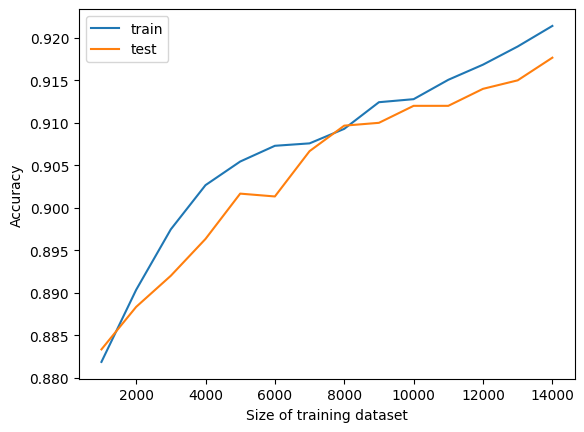

In [19]:
# CODE GOES HERE
plt.plot(sizes, train_scores, label="train")
plt.plot(sizes, test_scores, label="test")
plt.xlabel("Size of training dataset")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Analyze the results.  If we want to improve the model's test set accuracy, what should we do -- add more training data, or choose a different model?

As the training set sizes increases, so does both the test and training accuracy. In the last run there was a training set accuracy of 0.921 and a test set accuracy of 0.917 resulting in a bias of 7.9% and variance of 0.39%. This indicates that our model needs improvement in bias which could come from a more complex model.  